# Excecuting price prediction

In [61]:

import pandas as pd 
import numpy as np 
import yfinance 

import matplotlib.pyplot as plt
import torch 

import DataDownload # Download stock data from Yahho Finance 
import LinearModel # Linear NN model. 


In [62]:
tickers = ['AAPL','GOOG','^GSPC'] # tickers 
tickers_crypto = ['BTC-USD','ETH-USD'] # tickers for crypto currencies
start = '2024-09-01'    # start date
end  = '2026-05-01'     # end date
interval = '4h'         # interval

df = DataDownload.download_data(tickers, start, end, interval).dropna()

df_crypto = DataDownload.download_data(tickers_crypto, start, end, interval).dropna()

df


[*********************100%***********************]  3 of 3 completed
[*********************100%***********************]  2 of 2 completed


Price                           Close                                 High  \
Ticker                           AAPL        GOOG        ^GSPC        AAPL   
Datetime                                                                     
2024-09-03 13:30:00-04:00  222.750000  158.639999  5529.109863  223.919998   
2024-09-04 09:30:00-04:00  220.119995  158.240005  5521.089844  221.755005   
2024-09-04 13:30:00-04:00  220.789993  157.800003  5519.089844  221.430099   
2024-09-05 09:30:00-04:00  222.389999  157.890503  5486.500000  225.479996   
2024-09-05 13:30:00-04:00  222.399994  158.589996  5503.120117  223.899994   
...                               ...         ...          ...         ...   
2026-04-28 13:30:00-04:00  270.760010  347.510010  7139.240234  270.945007   
2026-04-29 09:30:00-04:00  270.200012  347.261993  7121.950195  271.040009   
2026-04-29 13:30:00-04:00  270.190002  347.679993  7137.560059  270.589996   
2026-04-30 09:30:00-04:00  272.785004  380.640015  7181.370117  273.760010   
2026-04-30 13:30:00-04:00  271.359985  382.000000  7209.629883  275.940002   

Price                                                      Low              \
Ticker                           GOOG        ^GSPC        AAPL        GOOG   
Datetime                                                                     
2024-09-03 13:30:00-04:00  160.679993  5565.600098  221.169998  157.860001   
2024-09-04 09:30:00-04:00  160.399994  5552.990234  217.479996  157.960007   
2024-09-04 13:30:00-04:00  158.455002  5528.060059  220.070007  157.440002   
2024-09-05 09:30:00-04:00  160.910004  5546.299805  221.889999  157.839996   
2024-09-05 13:30:00-04:00  159.119995  5519.220215  221.810104  157.895004   
...                               ...          ...         ...         ...   
2026-04-28 13:30:00-04:00  348.600006  7144.959961  269.790009  346.510010   
2026-04-29 09:30:00-04:00  353.390015  7145.629883  267.040009  342.429993   
2026-04-29 13:30:00-04:00  349.510010  7138.600098  269.369995  346.380005   
2026-04-30 09:30:00-04:00  380.829987  7181.390137  268.140015  363.089996   
2026-04-30 13:30:00-04:00  382.630005  7219.830078  270.339996  377.700012   

Price                                         Open  ... open_close_log_diff  \
Ticker                           ^GSPC        AAPL  ...                AAPL   
Datetime                                            ...                       
2024-09-03 13:30:00-04:00  5504.330078  223.825195  ...           -0.000028   
2024-09-04 09:30:00-04:00  5506.680176  221.660004  ...           -0.004905   
2024-09-04 13:30:00-04:00  5503.660156  220.104599  ...           -0.000070   
2024-09-05 09:30:00-04:00  5480.540039  222.500000  ...            0.007715   
2024-09-05 13:30:00-04:00  5486.229980  222.397705  ...            0.000035   
...                                ...         ...  ...                 ...   
2026-04-28 13:30:00-04:00  7124.709961  269.869995  ...            0.000000   
2026-04-29 09:30:00-04:00  7112.669922  267.549988  ...           -0.011926   
2026-04-29 13:30:00-04:00  7107.859863  270.209991  ...            0.000037   
2026-04-30 09:30:00-04:00  7126.149902  270.500000  ...            0.001147   
2026-04-30 13:30:00-04:00  7181.120117  272.809998  ...            0.000092   

Price                     overnight_log_gap close_log_return  \
Ticker                                 AAPL             GOOG   
Datetime                                                       
2024-09-03 13:30:00-04:00         -0.021152        -0.012279   
2024-09-04 09:30:00-04:00         -0.009721        -0.002525   
2024-09-04 13:30:00-04:00         -0.007042        -0.002784   
2024-09-05 09:30:00-04:00          0.010824         0.000573   
2024-09-05 13:30:00-04:00         -0.000460         0.004420   
...                                     ...              ...   
2026-04-28 13:30:00-04:00         -0.009093         0.002593   
2026-04-29 09:30:00-04:00         -0.008634        -0.000714   
202

## Stock price visualization

In [ ]:
def plot_dataframe(data, ticker, column, ax=plt, display_percentage = False):
    if display_percentage == True:
        ax.plot(
            pd.to_datetime(data.index),np.exp(data[(column,ticker)]) * 100 - 100,
            label = ticker + " " + column 
        )
    else:
        ax.plot(
            pd.to_datetime(data.index),data[(column,ticker)],
            label = ticker + " " + column 
        )

def multiplot_dataframe(data, tickers, column, ax=plt, display_percentage = False):
    for t in tickers:
        plot_dataframe(data,t,column,ax, display_percentage)
    plt.title(
        'Multiple '+column
        )
    plt.legend(frameon= False)
    plt.xlabel('Time')
    if 'log' in column:
        plt.ylabel('Log Return' if display_percentage == False else 'Percentage return (%)')
    else:
        plt.ylabel('Stock price (USD)')
        # plt.ylabel('Stock Price (USD)')
    # plt.ylabel('Stock Price (L)' if display_percentage == False else )

### Bare log return for stocks

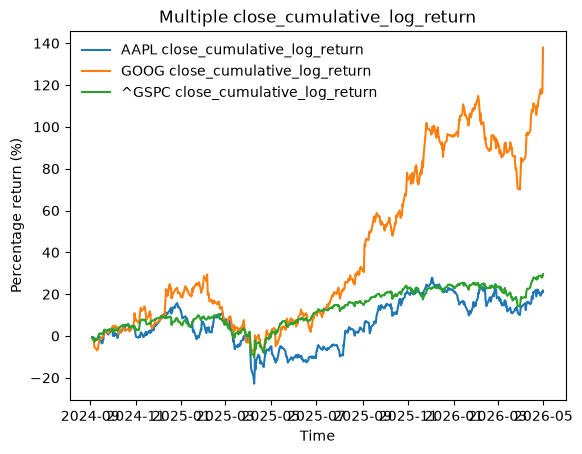

In [64]:
multiplot_dataframe(df,tickers,'close_cumulative_log_return',display_percentage=True)
# multiplot_dataframe(df_crypto,tickers_crypto,'close_cumulative_log_return',display_percentage=True)

In [65]:
# Time horizon for the time series 
max_lags = 4 
# Forecast horizon 
forecast_horizon = 1 
# Sharpe annualized rate 
annualized_rate = np.sqrt(252)
annualized_rate_crypto = np.sqrt(365)

## Setup the Neural Network 

In [66]:
input_features = 1
model = LinearModel.LinearModel(input_features) # Generate a linear model class 
# Print model summary 
print(model)

LinearModel(
  (linear): Linear(in_features=1, out_features=1, bias=True)
)


In [67]:
# Generated the lagged data as features
def features_lag_(data: pd.DataFrame, lag, symbol):
    df = pd.DataFrame(index = data.index.copy())
    df["close_log_return"] = data[("close_log_return", symbol)]
    if lag == 0:
        raise ValueError("lag must be greater than 0")
    if type(lag) != int:
        raise TypeError("lag must int")
    
    i = 1
    while i < lag + 1 :
        name = 'close_log_return_lag_' + str(i)
        df[name] = data[("close_log_return", symbol)].shift(i)
        i += 1
    
    return df

df_lag_aapl = features_lag_(df, max_lags, "AAPL").dropna()
df_lag_aapl

,close_log_return,close_log_return_lag_1,close_log_return_lag_2,close_log_return_lag_3,close_log_return_lag_4
Datetime,,,,,
2024-09-05 13:30:00-04:00,0.000045,0.007221,0.003039,-0.011877,-0.004843
2024-09-06 09:30:00-04:00,-0.006405,0.000045,0.007221,0.003039,-0.011877
2024-09-06 13:30:00-04:00,-0.000317,-0.006405,0.000045,0.007221,0.003039
2024-09-09 09:30:00-04:00,-0.000317,-0.000317,-0.006405,0.000045,0.007221
2024-09-09 13:30:00-04:00,0.000679,-0.000317,-0.000317,-0.006405,0.000045
...,...,...,...,...,...
2026-04-28 13:30:00-04:00,0.003293,0.008148,0.003143,-0.015691,0.003678
2026-04-29 09:30:00-04:00,-0.002070,0.003293,0.008148,0.003143,-0.015691
2026-04-29 13:30:00-04:00,-0.000037,-0.002070,0.003293,0.008148,0.003143


In [68]:

train_ticker = "BTC-USD"
features = ['close_log_return_lag_1','close_log_return_lag_2','close_log_return_lag_3','close_log_return_lag_4']
target = ["close_log_return"]
train_ratio = 0.75 

# df_lag = features_lag_(df, max_lags, train_ticker).dropna()

# train_idx = int(len(df_lag)*train_ratio)
# df_train, df_test = df_lag[:train_idx], df_lag[train_idx:]


def get_train_test_features(data, train_ticker, features, target, train_ratio):
    df_lag = features_lag_(data, max_lags, train_ticker).dropna()
    train_idx = int(len(df_lag)*train_ratio)
    df_train, df_test = df_lag[:train_idx], df_lag[train_idx:]
    # Features
    F_train = torch.tensor(df_train[features].to_numpy(),dtype = torch.float32)
    F_test = torch.tensor(df_test[features].to_numpy(),dtype = torch.float32)

    # Targets
    T_train = torch.tensor(df_train[target].to_numpy(),dtype = torch.float32)
    T_test = torch.tensor(df_test[target].to_numpy(),dtype = torch.float32)
    return F_train, F_test, T_train, T_test

# F_train,F_test,T_train,T_test = get_train_test_features(
#     df, train_ticker, features, target, train_ratio = train_ratio
# )

F_train,F_test,T_train,T_test = get_train_test_features(
    df_crypto, train_ticker, features, target, train_ratio = train_ratio
)

In [69]:
F_train.shape

torch.Size([2700, 4])

In [70]:
T_train.shape

torch.Size([2700, 1])

# Batch Gradient Descend

In [ ]:
no_epochs = 50_000
lossrate = 0.0001
rtol = 1e-4

# Create model 
model = LinearModel.LinearModel(len(features))
# Loss Function
LossFunction = torch.nn.MSELoss()
# optimizer
optimizer = torch.optim.Adam(model.parameters(),lr = lossrate)

print("\nTraining model...")
train_loss_log = 0 
for epoch in range(no_epochs):
    # forward prediction
    T_hat = model(F_train)
    loss = LossFunction(T_hat, T_train)
    
    # backward pass 
    optimizer.zero_grad()   # drop old gradient
    loss.backward()         # compute new gradient
    optimizer.step()        # update weights
    
    train_loss = loss.item()
    
    rel_loss = np.abs(train_loss-train_loss_log)/(np.abs(train_loss))
    
    if rel_loss < rtol:
        print(f"Relative Tolance Reached at Epoch {epoch}")
        break
    
    train_loss_log = train_loss
    if epoch % 500 == 0: 
        print(f"Epoch {epoch}/{no_epochs}, Loss = {train_loss:.9f}")
                
print("\n Training Finished!", f"\n Loss = {train_loss:.9f}")



Training model...
Epoch 0/50000, Loss = 0.019510856
Epoch 500/50000, Loss = 0.008856741
Epoch 1000/50000, Loss = 0.003371365
Epoch 1500/50000, Loss = 0.001036246
Epoch 2000/50000, Loss = 0.000288013
Epoch 2500/50000, Loss = 0.000127609
Relative Tolance Reached at Epoch 2996

 Training Finished! 
 Loss = 0.000106757


In [72]:
# Evaluate the model 
model.eval()

with torch.no_grad():
    T_train_hat = model(F_train)
    T_hat = model(F_test)
    test_loss = LossFunction(T_hat, T_test)
    print(f"\nTest Loss = {test_loss.item():.9f}", 
          f"\nTrain Loss = {train_loss:.9f}")


Test Loss = 0.000101456 
Train Loss = 0.000106757


In [ ]:
model_parameter

## Trading performance of the model

It should be emphasized that no model can make perfectly accurate predictions. However, we can still extract some information out of the mode.

In [73]:
trade_train = pd.DataFrame(
          {  "T_train": T_train.squeeze(),
        "T_train_prediction": T_train_hat.squeeze()}
)

t_hat = T_hat.squeeze().numpy()
t_test = T_test.squeeze().numpy()

def get_trade_results(t_hat,t_test):
    df = pd.DataFrame({
        "T_hat": t_hat,
        "T_test": t_test,
        "signal": np.sign(t_hat),
        "is_won": (np.sign(t_hat*t_test) == 1),
        "trade_log_return": t_test * np.sign(t_hat)
        })
    
    df['trade_log_return_cum'] = df['trade_log_return'].cumsum()
    df['drawdown_log'] = df['trade_log_return'] - df['trade_log_return'].cummax()
    
    return df 
            # "equity_log_cum": trade_results["equity_log"].cumsum(),
        # 'drawdown_log': trade_results["porfolio_log"] - trade_results['equity_log_cum']
    
def get_model_performance(model):
    # Evaluate the model 
    model.eval()

    with torch.no_grad():
        T_train_hat = model(F_train)
        T_hat = model(F_test)
        test_loss = LossFunction(T_hat, T_test)
        print(f"\nTest Loss = {test_loss.item():.9f}", 
            f"\nTrain Loss = {train_loss:.9f}")
    ##############
    ##############
    # Get predictions as numpy arrays 
    t_hat = T_hat.squeeze().numpy()
    t_test = T_test.squeeze().numpy()
    
    df = get_trade_results(t_hat, t_test)
    #####################
    # Get model params
    #####################
    
    max_drawdown_log = df['drawdown_log'].min()
    drawdown_percentage = np.exp(max_drawdown_log) - 1
    win_rate = df['is_won'].mean()
    average_win = df[df['is_won']==True]['trade_log_return'].mean()
    average_loss = df[df['is_won'] == False]['trade_log_return'].mean()
    ev = win_rate * average_win + (1-win_rate) * average_loss
    total_log_return = df['trade_log_return'].sum()
    compund_return = np.exp(total_log_return)
    
    equity_trough = df['trade_log_return_cum'].min() 
    equity_peak = df['trade_log_return_cum'].max()
    
    std = df['trade_log_return'].std()
    
    sharpe = ev/std * np.sqrt(252) # Sharp for stocks 
    sharpe_crypto = ev/std * np.sqrt(365) # Sharpe for cryptos
    
    
    print(
        f"\nMaximum drawdown (log): {max_drawdown_log:.6f}"
        f"\nDrawdown percentage: {drawdown_percentage:.2%}"
        f"\nWin rate: {win_rate:.2%}"
        f"\nAverage win: {average_win:.6f}"
        f"\nAverage loss: {average_loss:.6f}"
        f"\nExpected value per trade: {ev:.6f}"
        f"\nTotal log return: {total_log_return:.6f}"
        f"\nCompounded return: {compund_return - 1:.2%}"
        f"\nEquity multiplier: {compund_return:.4f}x"
        f"\nMinimum trade log return: {equity_trough:.6f}"
        f"\nMaximum trade log return: {equity_peak:.6f}"
        f"\nStandard deviation: {std:.6f}"
        f"\nAnnualized Sharpe (stocks): {sharpe:.4f}"
        f"\nAnnualized Sharpe (crypto): {sharpe_crypto:.4f}"
    )
    return     

get_model_performance(model)


Test Loss = 0.000101456 
Train Loss = 0.000106757

Maximum drawdown (log): -0.088241
Drawdown percentage: -8.45%
Win rate: 49.94%
Average win: 0.006704
Average loss: -0.006869
Expected value per trade: -0.000090
Total log return: -0.080953
Compounded return: -7.78%
Equity multiplier: 0.9222x
Minimum trade log return: -0.186465
Maximum trade log return: 0.142732
Standard deviation: 0.009858
Annualized Sharpe (stocks): -0.1447
Annualized Sharpe (crypto): -0.1741


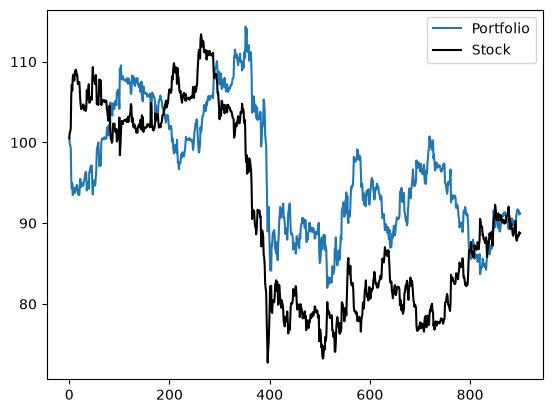

In [74]:
trade_results = get_trade_results(t_hat,t_test)

plt.plot(np.exp(trade_results["trade_log_return"].cumsum())*100-1,label='Portfolio')
plt.plot(np.exp(trade_results["T_test"].cumsum())*100-1,c='black',label='Stock')
plt.legend()
# plt.plot((df[('close_log_return','AAPL')]).cumsum()*100 -1)

# plt.plot(t_test,c='black')